In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [4]:
# Importing the dataset for Temperatur of every year
# Read the temperature data from CSV files with a loop
# Create a list of years
years = ['22', '21', '20', '19', '03', '90', '80', '70']
# loop through every year and name the df after the year
for year in years:
    # globals are used to create a variable from a string
    globals()['df_{}'.format(year)] = pd.read_csv('TEMP/TEMP_{}.csv'.format(year))



In [7]:
df_22.head(1)

,latitude,longitude,country,population,id,city,jan,feb,mar,apr,may,jun,jul,aug,sep,oct,nov,dec
0,39.87534,20.00477,AL,15147,363243,Sarandë,10.5,11.28,10.33,15.01,20.08,25.69,27.42,27.23,23.6,20.35,16.65,14.63


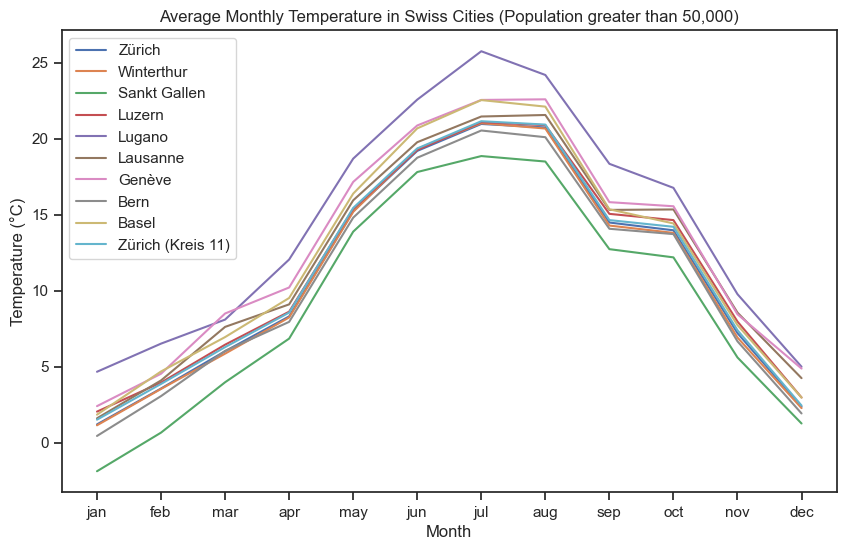

In [19]:
# Only plotting one country == switzerland
# Select only the cities from Switzerland (country code 'CH') with a population of 50,000 or more
df_22_ch_filtered = df_22[(df_22['country'] == 'CH') & (df_22['population'] >= 50000)]

# Extract the month columns
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Create a line plot for every filtered city in Switzerland
plt.figure(figsize=(10, 6))
for city in df_22_ch_filtered['city'].unique():
    city_df = df_22_ch_filtered[df_22_ch_filtered['city'] == city]
    temperatures = city_df[months].values.squeeze()
    plt.plot(months, temperatures, label=city)

# Set plot title and labels
plt.title("Average Monthly Temperature in Swiss Cities (Population greater than 50,000)")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

# Add a legend
plt.legend()

# Show the plot
plt.show()


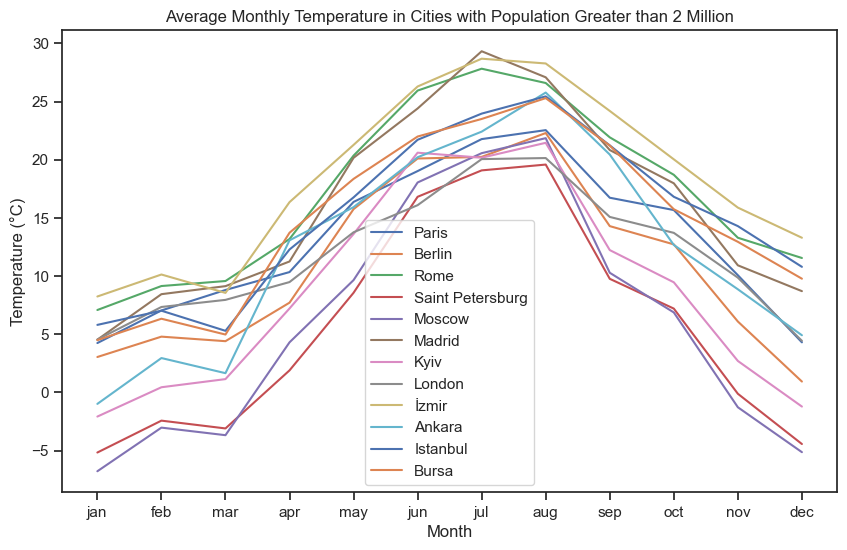

In [24]:
# the same for every city with greater population than 500000
# Select only the cities with a population of 500,000 or more
df_22_filtered = df_22[df_22['population'] >= 2000000]

# Create a line plot for every filtered city
plt.figure(figsize=(10, 6))
for city in df_22_filtered['city'].unique():
    city_df = df_22_filtered[df_22_filtered['city'] == city]
    temperatures = city_df[months].values.squeeze()
    plt.plot(months, temperatures, label=city)

# Set plot title and labels
plt.title("Average Monthly Temperature in Cities with Population Greater than 2 Million")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

# Add a legend
plt.legend()

# Show the plot
plt.show()

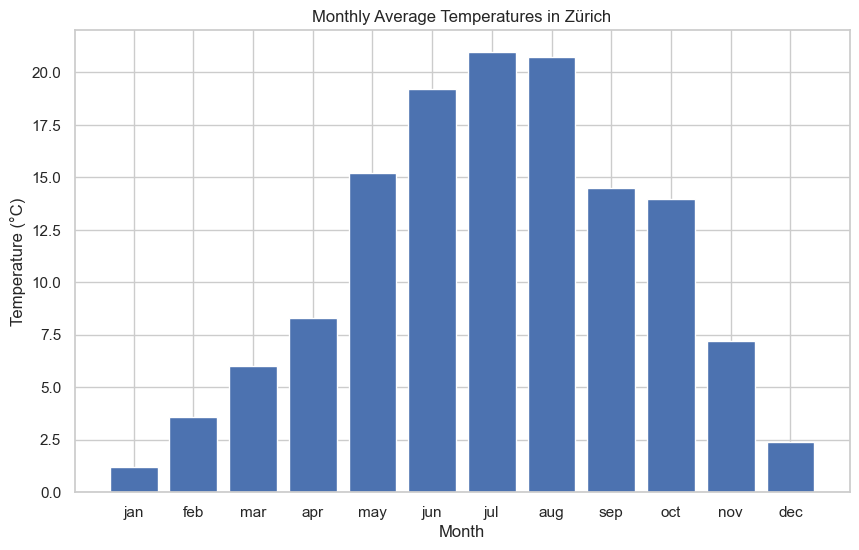

In [28]:

# Bar plot of monthly average temperatures for a specific city
city_name = 'Zürich'
city_df = df_22[df_22['city'] == city_name]
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
temperatures = city_df[months].values.squeeze()

plt.figure(figsize=(10, 6))
plt.bar(months, temperatures)
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.title(f'Monthly Average Temperatures in {city_name}')
plt.show()


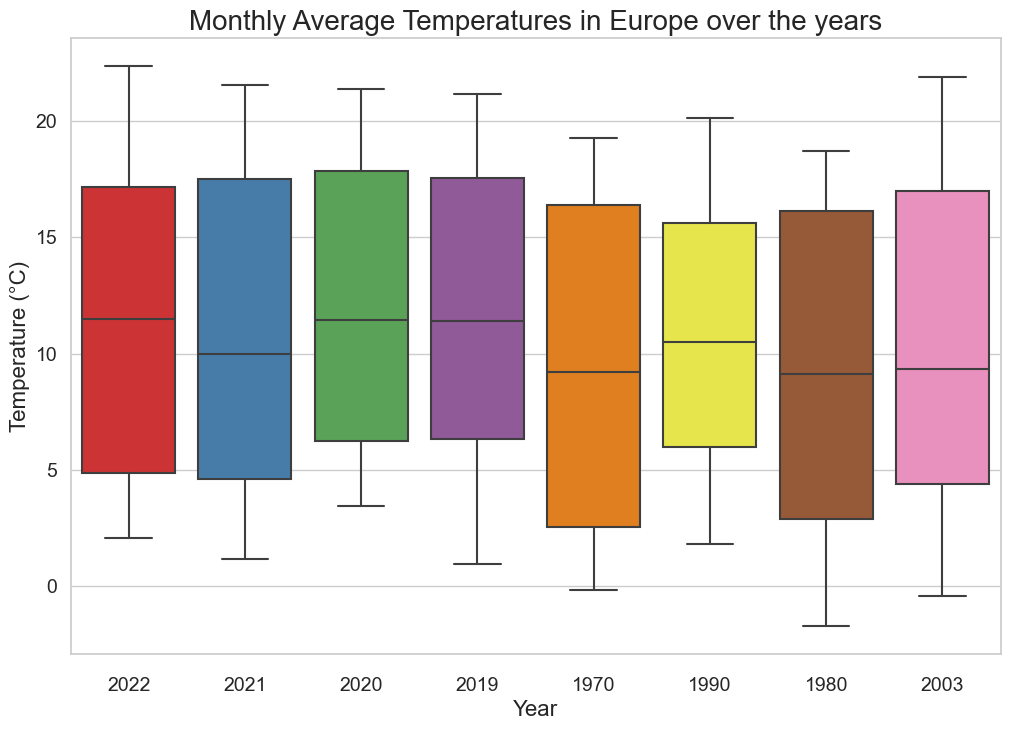

In [29]:

# Calculate average temperature for each month
monthly_avg_temps_22 = df_22[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()
monthly_avg_temps_21 = df_21[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()
monthly_avg_temps_20 = df_20[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()
monthly_avg_temps_19 = df_19[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()
monthly_avg_temps_03 = df_03[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()
monthly_avg_temps_90 = df_90[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()
monthly_avg_temps_80 = df_80[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()
monthly_avg_temps_70 = df_70[['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']].mean()

# Combine all monthly average temperatures into one dataframe
df = pd.concat([monthly_avg_temps_22, monthly_avg_temps_21, monthly_avg_temps_20, monthly_avg_temps_19,
                monthly_avg_temps_70, monthly_avg_temps_90, monthly_avg_temps_80, monthly_avg_temps_03], axis=1)
df.columns = ['2022', '2021', '2020', '2019', '1970', '1990', '1980', '2003']

# Set plot style
sns.set_style('whitegrid')

# Define color palette
palette = sns.color_palette('Set1', n_colors=8)

# Create violin plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.boxplot(data=df, palette=palette)

# Set plot title and axis labels
ax.set_title('Monthly Average Temperatures in Europe over the years', fontsize=20)
ax.set_xlabel('Year', fontsize=16)
ax.set_ylabel('Temperature (°C)', fontsize=16)

# Customize tick labels and font size
ax.tick_params(axis='both', labelsize=14)
ax.tick_params(axis='x', pad=10)

plt.show()

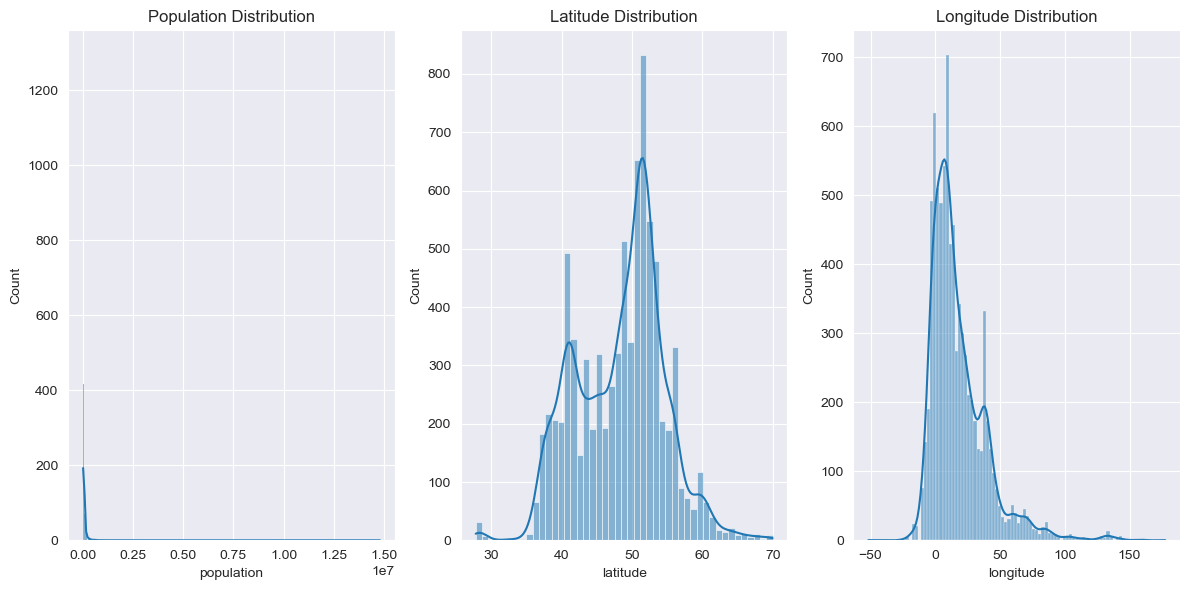

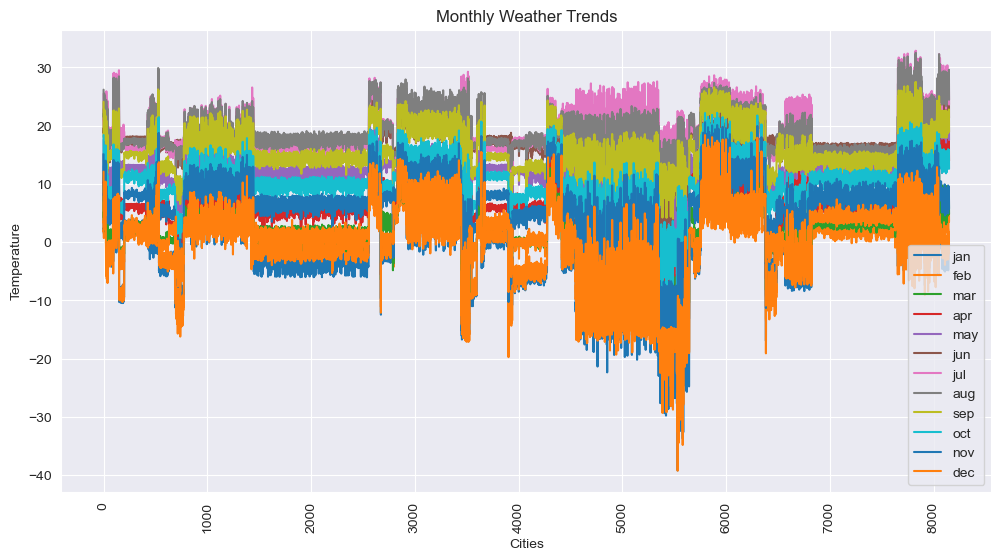

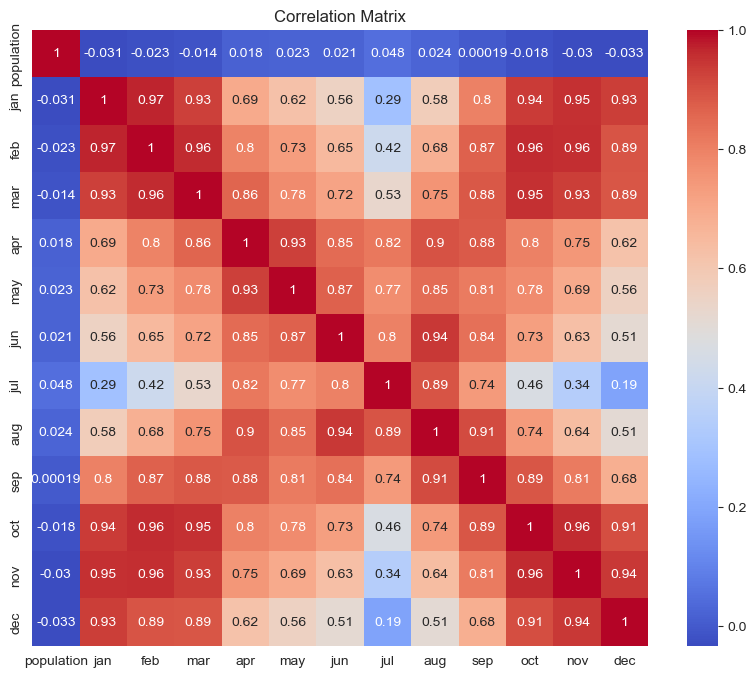

In [19]:
# Data Distribution
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
sns.histplot(data=df, x='population', kde=True)
plt.title('Population Distribution')

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='latitude', kde=True)
plt.title('Latitude Distribution')

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='longitude', kde=True)
plt.title('Longitude Distribution')

plt.tight_layout()
plt.show()

# Weather Trends
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

plt.figure(figsize=(12, 6))
for month in months:
    plt.plot(df[month], label=month)
plt.xlabel('Cities')
plt.ylabel('Temperature')
plt.title('Monthly Weather Trends')
plt.legend()
plt.xticks(rotation=90)
plt.show()

# Correlation Analysis
numeric_cols = ['population', 'jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()


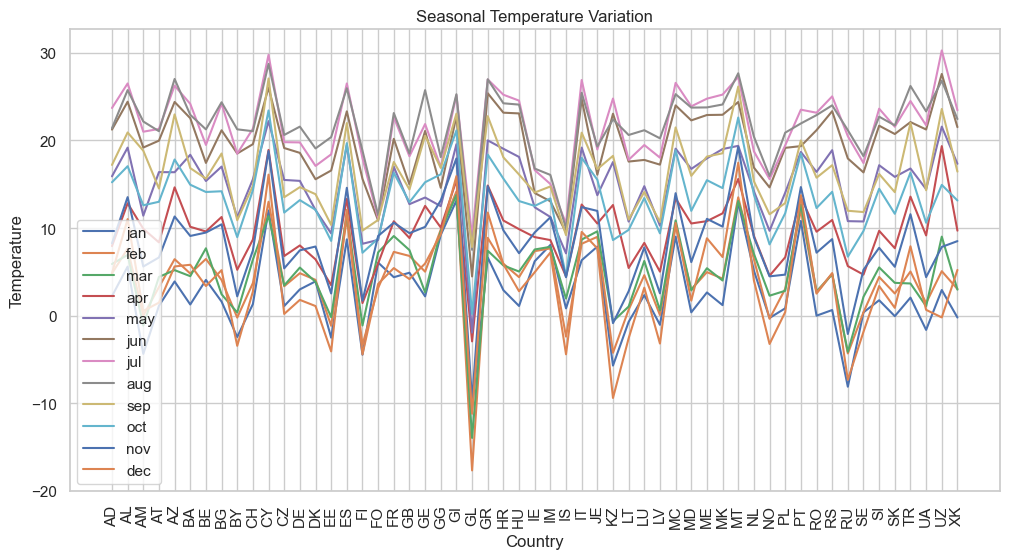

In [32]:
# Seasonal Trends
seasons = {
    'Winter': ['dec', 'jan', 'feb'],
    'Spring': ['mar', 'apr', 'may'],
    'Summer': ['jun', 'jul', 'aug'],
    'Autumn': ['sep', 'oct', 'nov']
}

seasonal_data = df_22.groupby('country')[months].mean()
seasonal_data = seasonal_data.rename(columns=seasons)

plt.figure(figsize=(12, 6))
for season in seasonal_data.columns:
    plt.plot(seasonal_data.index, seasonal_data[season], label=season)
plt.xlabel('Country')
plt.ylabel('Temperature')
plt.title('Seasonal Temperature Variation')
plt.legend()
plt.xticks(rotation=90)
plt.show()


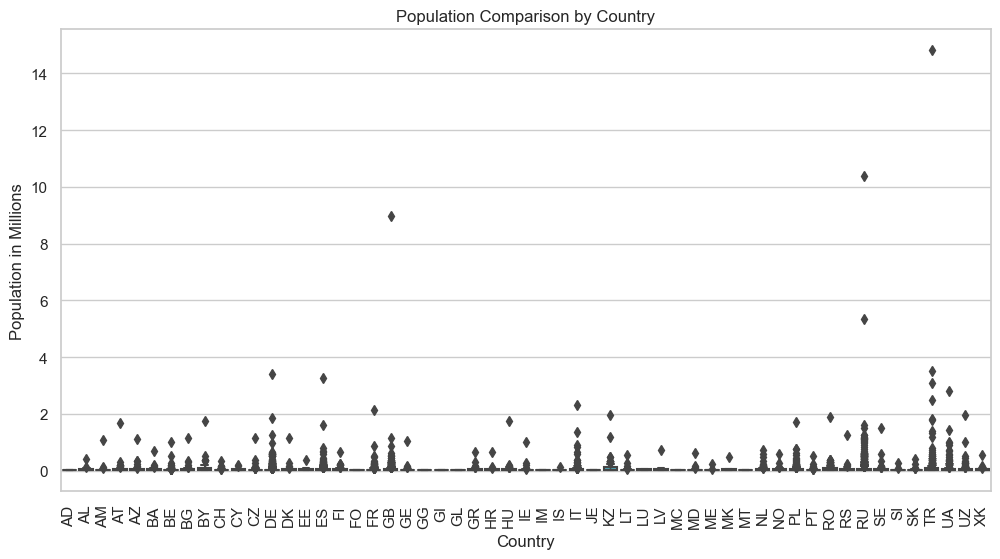

In [47]:

# Assuming you have already loaded the DataFrame
df_22['population_in_mio'] = df_22['population'] / 1000000
# Create a comparative analysis plot using a boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_22, x='country', y='population_in_mio')
plt.title('Population Comparison by Country')
plt.xlabel('Country')
plt.ylabel('Population in Millions')
plt.xticks(rotation=90)
plt.show()